In [1]:
import earthkit.data
import earthkit.plots
import numpy as np

data = earthkit.data.from_source("sample", "healpix-h128-nested-2t.grib")

style = earthkit.plots.styles.Style(
    levels=np.arange(0, 20, 0.5),
    colors="Spectral_r",
    units="celsius",
)

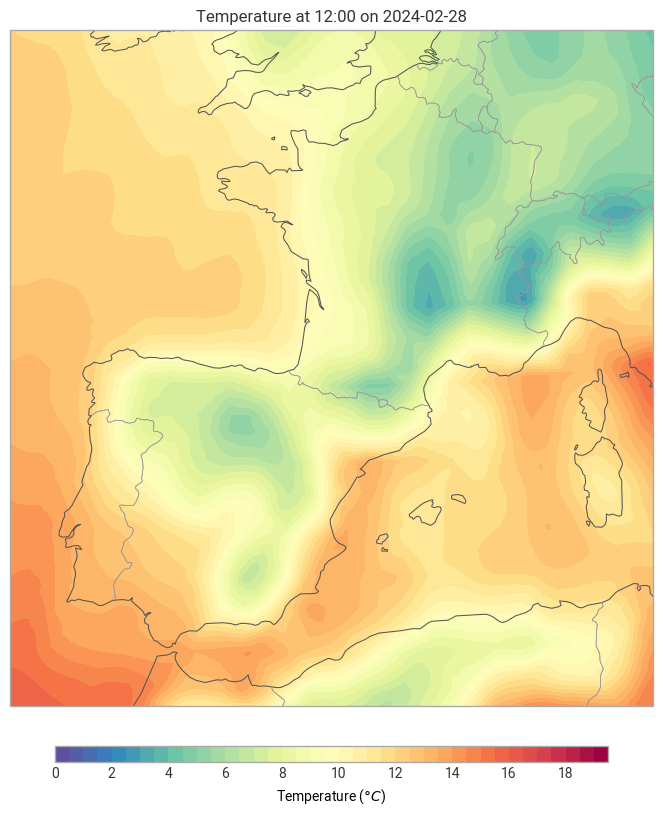

In [2]:
chart = earthkit.plots.Map(domain=["France", "Spain"])

chart.quickplot(data, style=style)

chart.title()
chart.legend()

chart.coastlines()
chart.borders()

chart.show()

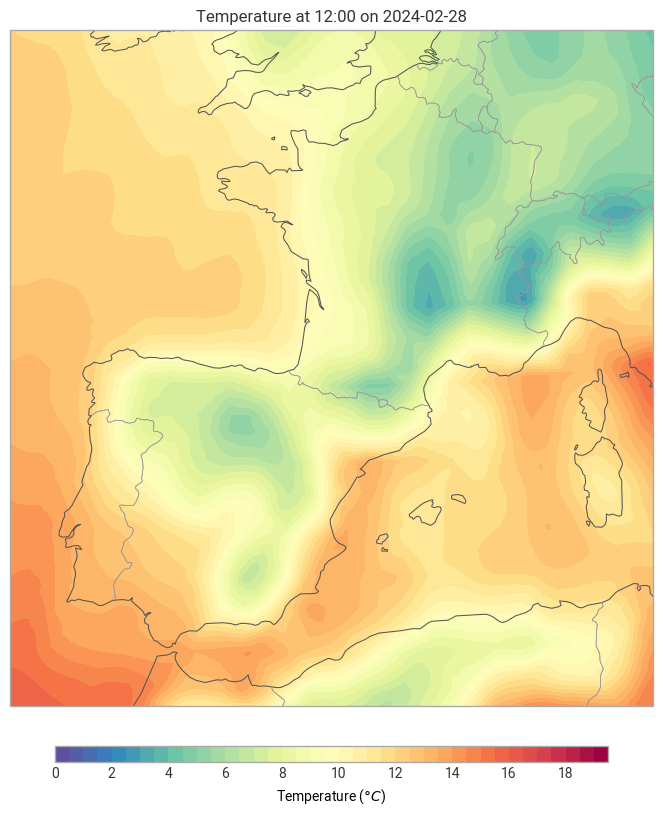

In [3]:
chart = earthkit.plots.Map(domain=["France", "Spain"])

chart.contourf(data, style=style)

chart.title()
chart.legend()

chart.coastlines()
chart.borders()

chart.show()

In [4]:
from earthkit.plots.resample import Regrid, Bilinear

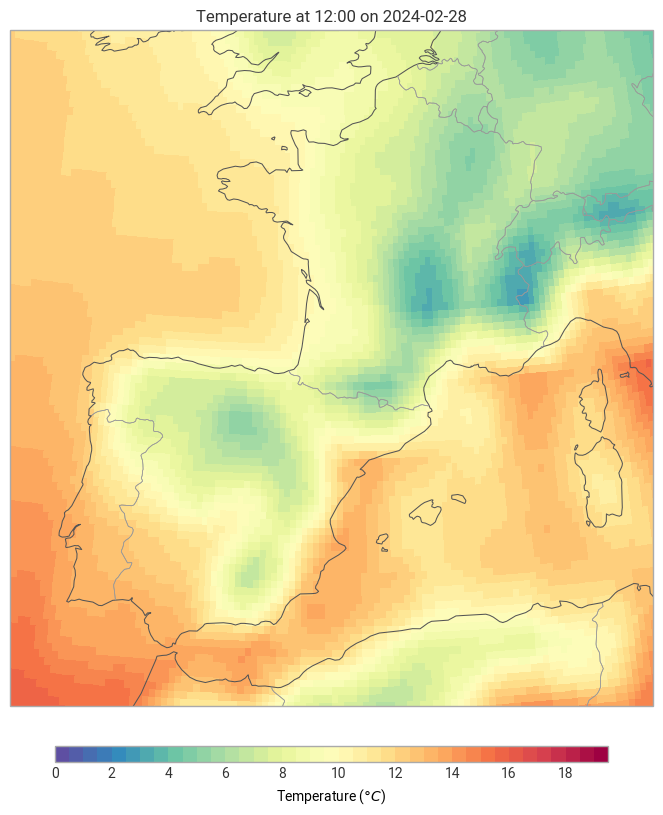

In [5]:
chart = earthkit.plots.Map(domain=["France", "Spain"])

chart.pcolormesh(data, style=style, resample=Regrid())

chart.title()
chart.legend()
# chart.gridlines(xstep=1, ystep=1)

chart.coastlines()
chart.borders()

chart.show()

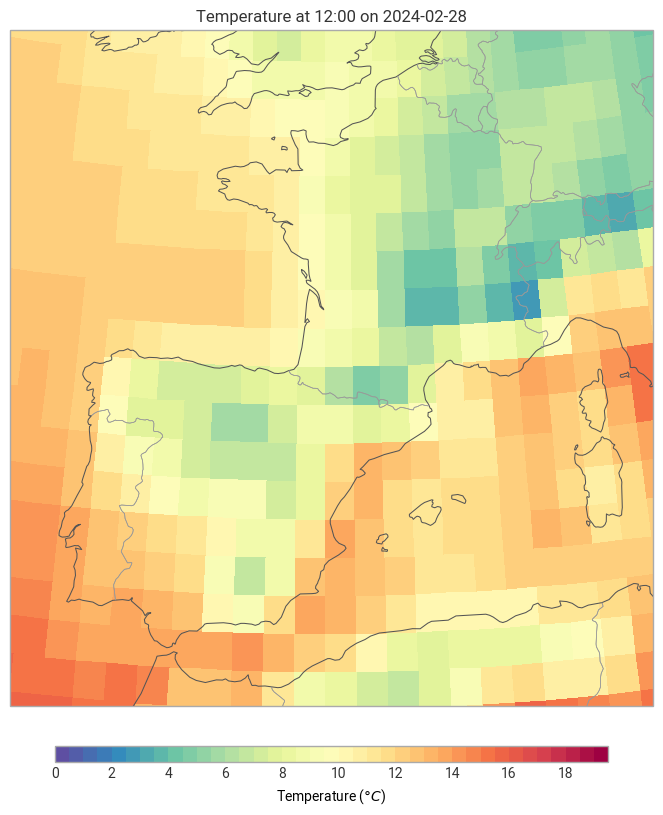

In [6]:
chart = earthkit.plots.Map(domain=["France", "Spain"])

chart.pcolormesh(
    data,
    style=style,
    resample=Regrid(
        in_grid={"grid": "H128", "order": "nested"},
        out_grid={"grid": [1, 1]},
    ),
)

chart.title()
chart.legend()

chart.coastlines()
chart.borders()

chart.show()

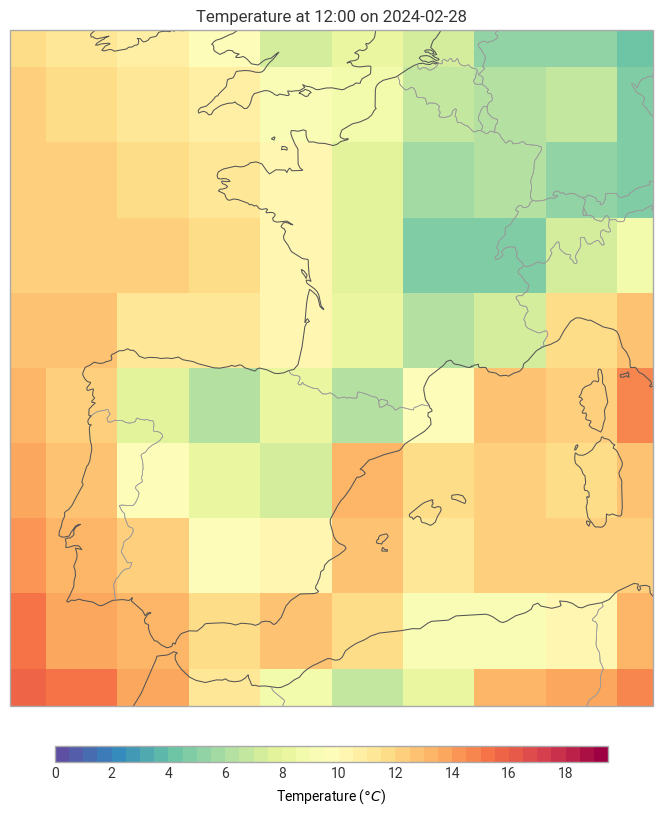

In [7]:
chart = earthkit.plots.Map(domain=["France", "Spain"])

chart.pcolormesh(
    data,
    style=style,
    resample=[Regrid(out_grid={"grid": [1, 1]}), Bilinear(nx=10, ny=10)],
)

chart.title()
chart.legend()

chart.coastlines()
chart.borders()

chart.show()

In [8]:
temperature, pressure = earthkit.data.from_source(
    "sample", "era5-2t-msl-1985122512.grib"
).to_fieldlist()

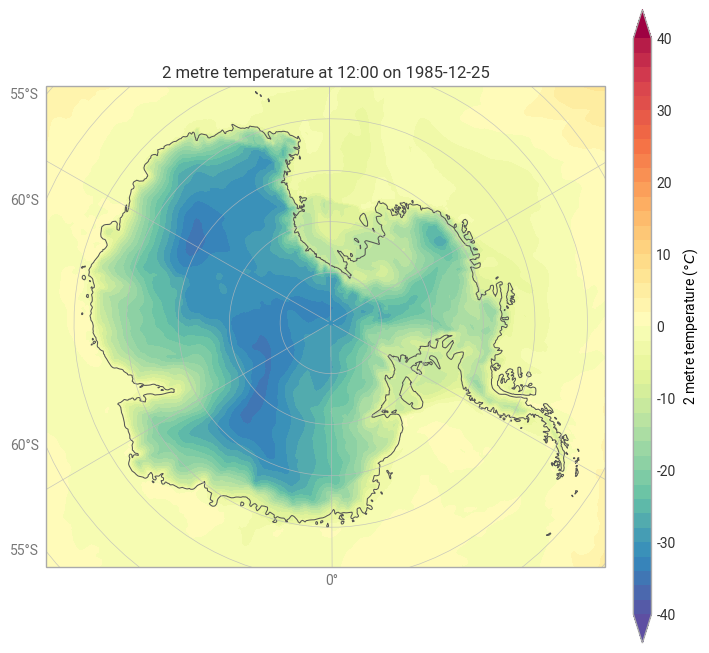

CPU times: user 16.6 s, sys: 85.2 ms, total: 16.7 s
Wall time: 16.8 s


In [9]:
%%time
chart = earthkit.plots.Map(domain="Antarctica")

chart.quickplot(temperature, units="celsius", resample=False)
# chart.quickplot(pressure, units="hPa", resample=False)

chart.legend(location="right")

chart.coastlines()

chart.title()
chart.gridlines()

chart.show()

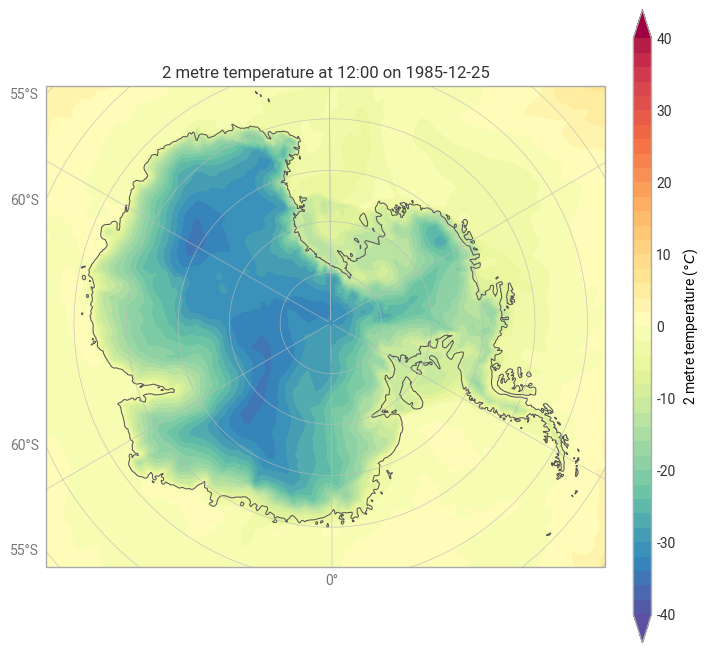

CPU times: user 1.39 s, sys: 49.2 ms, total: 1.44 s
Wall time: 1.38 s


In [10]:
%%time
chart = earthkit.plots.Map(domain="Antarctica")

chart.quickplot(temperature, units="celsius", resample=Bilinear(500))
# chart.quickplot(pressure, units="hPa")

chart.legend(location="right")

chart.coastlines(transform_first=True)

chart.title()
chart.gridlines()

chart.show()

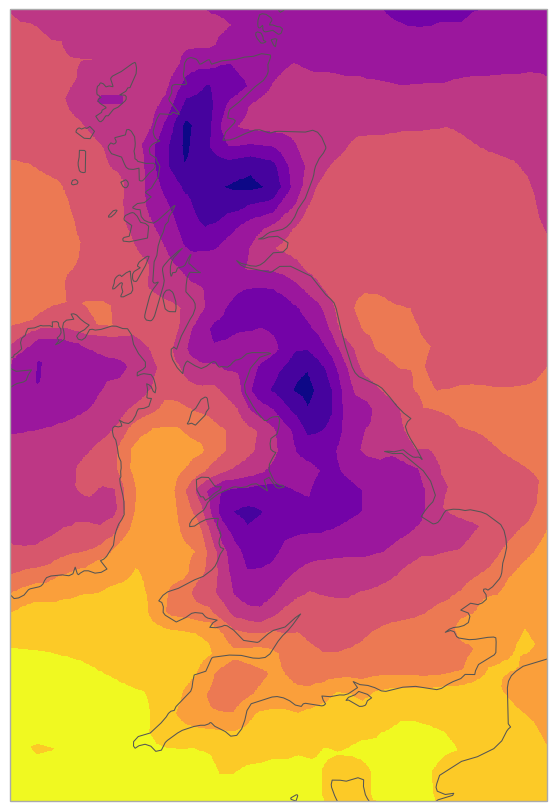

CPU times: user 1.6 s, sys: 89.3 ms, total: 1.69 s
Wall time: 1.48 s


In [11]:
%%time
chart = earthkit.plots.Map(domain="UK")

chart.pcolormesh(temperature, units="celsius", resample=Bilinear(nx=1000, ny=1000))

chart.coastlines()

chart.show()

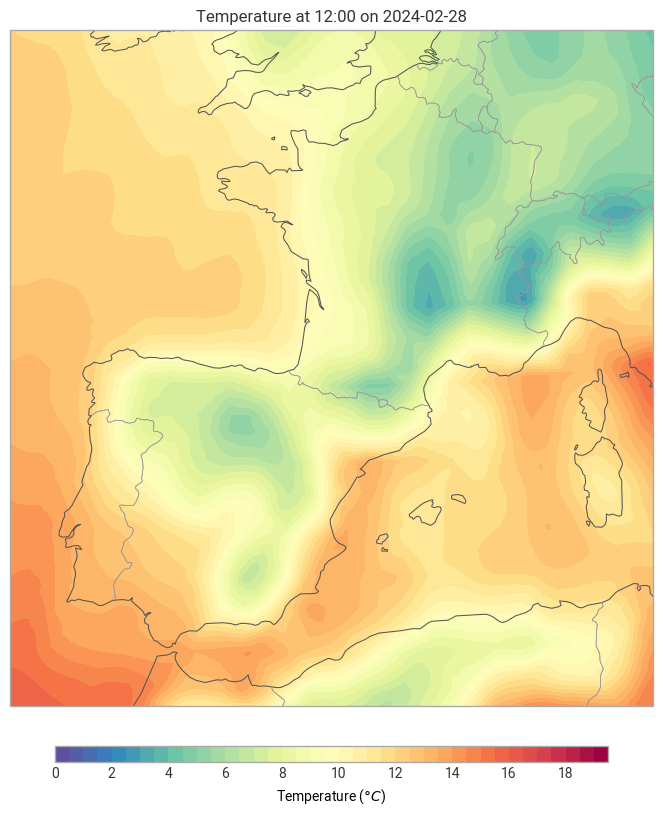

In [12]:
chart = earthkit.plots.Map(domain=["France", "Spain"])

chart.contourf(data, style=style, resample="auto")

chart.title()
chart.legend()

chart.coastlines()
chart.borders()

chart.show()